### First we generate language n-grams

In [41]:
from pathlib import Path
from collections import Counter

import pandas as pd
from nltk.util import ngrams

In [ ]:
def generate_character_ngrams(text, n=3):
    text = "_".join(text.lower().split())

    # Generate overlapping character n-grams and count their frequencies
    return Counter(
        ''.join(g)
        for g in ngrams(text, n)
    )

In [27]:
OUTPUT_DIR = Path("../data/ngrams")
OUTPUT_DIR.mkdir(exist_ok=True)

for language, text in corpora.items():
    counts = generate_character_ngrams(text, 3)

    df = (
        pd.DataFrame(
            counts.items(),
            columns=["ngram", "frequency"]
        )
        .sort_values("frequency", ascending=False)
        .reset_index(drop=True)
    )

    df.to_csv(
        OUTPUT_DIR / f"{language}_character_trigrams.csv",
        index=False
    )

    print(f"Saved {language}")

Saved Bikol
Saved Cebuano
Saved English
Saved Hiligaynon
Saved Ilocano
Saved Kapampangan
Saved Pangasinense
Saved Spanish
Saved Tagalog
Saved Waray


### Determining how many trigrams are taken into account

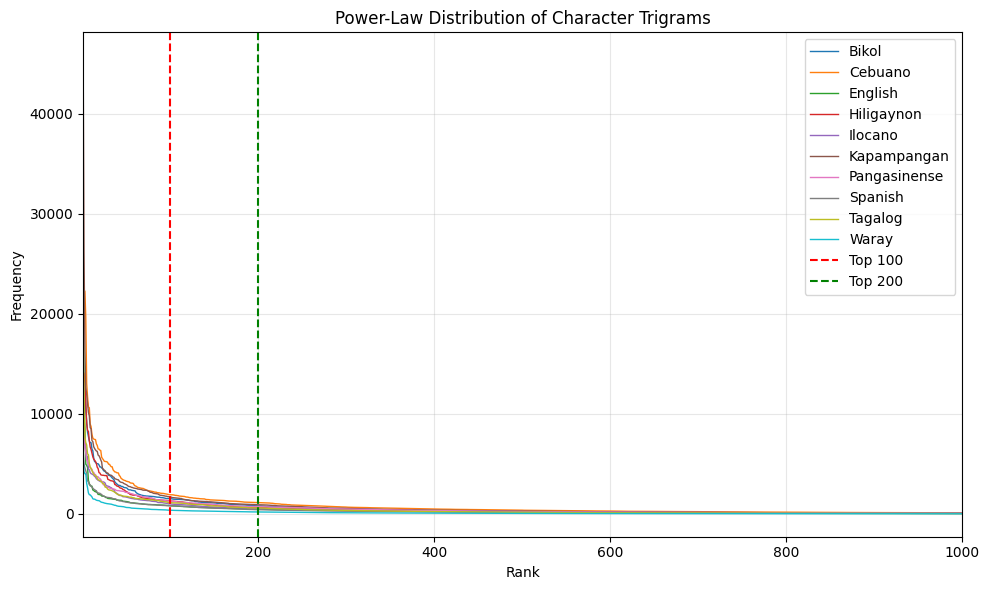

In [40]:
import matplotlib.pyplot as plt

MAX_RANK = 1000

plt.figure(figsize=(10, 6))

for language, text in corpora.items():
    counts = generate_character_ngrams(text, 3)

    frequencies = sorted(counts.values(), reverse=True)[:MAX_RANK]

    plt.plot(
        range(1, len(frequencies) + 1),
        frequencies,
        linewidth=1,
        label=language
    )

plt.axvline(100, color='red', linestyle='--', label='Top 100')
plt.axvline(200, color='green', linestyle='--', label='Top 200')

plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Power-Law Distribution of Character Trigrams")
plt.xlim(1, MAX_RANK)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [62]:
from pathlib import Path
import pandas as pd
import numpy as np

NGRAM_DIR = Path("../data/ngrams")

TOP_K = 100

language_vectors = {}
vocabulary = set()

# Read the top-k trigrams from every language
for file in NGRAM_DIR.glob("*_character_trigrams.csv"):
    language = file.stem.replace("_character_trigrams", "")

    df = (
        pd.read_csv(file,na_filter=False)
        .head(TOP_K)
    )

    freq_dict = dict(zip(df["ngram"], df["frequency"]))

    language_vectors[language] = freq_dict
    vocabulary.update(freq_dict.keys())

vocabulary = sorted(vocabulary)

print(f"{len(language_vectors)} languages")
print(f"{len(vocabulary)} unique trigrams")

10 languages
416 unique trigrams


In [63]:
aligned_vectors = {}

for language, freq_dict in language_vectors.items():
    aligned_vectors[language] = np.array([
        freq_dict.get(trigram, 0)
        for trigram in vocabulary
    ])

In [64]:
from sklearn.metrics.pairwise import cosine_similarity

languages = list(aligned_vectors.keys())

matrix = np.vstack([
    aligned_vectors[lang]
    for lang in languages
])

cosine_matrix = cosine_similarity(matrix)

cosine_df = pd.DataFrame(
    cosine_matrix,
    index=languages,
    columns=languages
)

cosine_df

,Bikol,Cebuano,English,Hiligaynon,Ilocano,Kapampangan,Pangasinense,Spanish,Tagalog,Waray
Bikol,1.000000,0.754973,0.105476,0.720740,0.383800,0.488108,0.673207,0.130321,0.718196,0.733554
Cebuano,0.754973,1.000000,0.109293,0.889493,0.337257,0.563663,0.517878,0.115325,0.841647,0.717415
English,0.105476,0.109293,1.000000,0.104279,0.062904,0.124401,0.149114,0.114377,0.128152,0.088842
Hiligaynon,0.720740,0.889493,0.104279,1.000000,0.352590,0.535793,0.499201,0.102283,0.822082,0.758534
Ilocano,0.383800,0.337257,0.062904,0.352590,1.000000,0.272462,0.449432,0.123843,0.336011,0.358884
Kapampangan,0.488108,0.563663,0.124401,0.535793,0.272462,1.000000,0.382953,0.065336,0.729665,0.281373
Pangasinense,0.673207,0.517878,0.149114,0.499201,0.449432,0.382953,1.000000,0.180394,0.498926,0.592472
Spanish,0.130321,0.115325,0.114377,0.102283,0.123843,0.065336,0.180394,1.000000,0.086548,0.118382
Tagalog,0.718196,0.841647,0.128152,0.822082,0.336011,0.729665,0.498926,0.086548,1.000000,0.568986
Waray,0.733554,0.717415,0.088842,0.758534,0.358884,0.281373,0.592472,0.118382,0.568986,1.000000


In [65]:
def dice_similarity(x, y):
    x = x > 0
    y = y > 0

    intersection = np.sum(x & y)

    return (2 * intersection) / (np.sum(x) + np.sum(y))

In [66]:
dice_matrix = np.zeros((len(languages), len(languages)))

for i, lang1 in enumerate(languages):
    for j, lang2 in enumerate(languages):
        dice_matrix[i, j] = dice_similarity(
            aligned_vectors[lang1],
            aligned_vectors[lang2]
        )

dice_df = pd.DataFrame(
    dice_matrix,
    index=languages,
    columns=languages
)

dice_df

,Bikol,Cebuano,English,Hiligaynon,Ilocano,Kapampangan,Pangasinense,Spanish,Tagalog,Waray
Bikol,1.00,0.64,0.09,0.66,0.45,0.44,0.48,0.20,0.60,0.64
Cebuano,0.64,1.00,0.09,0.71,0.43,0.48,0.48,0.18,0.64,0.62
English,0.09,0.09,1.00,0.10,0.13,0.10,0.19,0.23,0.13,0.11
Hiligaynon,0.66,0.71,0.10,1.00,0.43,0.41,0.48,0.15,0.61,0.66
Ilocano,0.45,0.43,0.13,0.43,1.00,0.41,0.56,0.19,0.47,0.43
Kapampangan,0.44,0.48,0.10,0.41,0.41,1.00,0.48,0.12,0.52,0.38
Pangasinense,0.48,0.48,0.19,0.48,0.56,0.48,1.00,0.21,0.50,0.52
Spanish,0.20,0.18,0.23,0.15,0.19,0.12,0.21,1.00,0.15,0.16
Tagalog,0.60,0.64,0.13,0.61,0.47,0.52,0.50,0.15,1.00,0.53
Waray,0.64,0.62,0.11,0.66,0.43,0.38,0.52,0.16,0.53,1.00


In [67]:
def extended_jaccard(x, y):
    numerator = np.dot(x, y)

    denominator = (
        np.dot(x, x)
        + np.dot(y, y)
        - numerator
    )

    return numerator / denominator

In [68]:
jaccard_matrix = np.zeros((len(languages), len(languages)))

for i, lang1 in enumerate(languages):
    for j, lang2 in enumerate(languages):
        jaccard_matrix[i, j] = extended_jaccard(
            aligned_vectors[lang1],
            aligned_vectors[lang2]
        )

jaccard_df = pd.DataFrame(
    jaccard_matrix,
    index=languages,
    columns=languages
)

jaccard_df

,Bikol,Cebuano,English,Hiligaynon,Ilocano,Kapampangan,Pangasinense,Spanish,Tagalog,Waray
Bikol,1.000000,0.562029,0.045013,0.558769,0.213361,0.289229,0.457590,0.046755,0.525521,0.234934
Cebuano,0.562029,1.000000,0.037582,0.692016,0.151240,0.389497,0.261902,0.031860,0.549229,0.164016
English,0.045013,0.037582,1.000000,0.047148,0.031578,0.039560,0.077265,0.058440,0.063802,0.038572
Hiligaynon,0.558769,0.692016,0.047148,1.000000,0.201310,0.307958,0.316593,0.039163,0.677672,0.273067
Ilocano,0.213361,0.151240,0.031578,0.201310,1.000000,0.110029,0.289448,0.058090,0.199774,0.149008
Kapampangan,0.289229,0.389497,0.039560,0.307958,0.110029,1.000000,0.167872,0.016259,0.407525,0.052837
Pangasinense,0.457590,0.261902,0.077265,0.316593,0.289448,0.167872,1.000000,0.084843,0.330691,0.261383
Spanish,0.046755,0.031860,0.058440,0.039163,0.058090,0.016259,0.084843,1.000000,0.037151,0.059039
Tagalog,0.525521,0.549229,0.063802,0.677672,0.199774,0.407525,0.330691,0.037151,1.000000,0.229414
Waray,0.234934,0.164016,0.038572,0.273067,0.149008,0.052837,0.261383,0.059039,0.229414,1.000000


In [69]:
def overlap_similarity(x, y):
    x = x > 0
    y = y > 0

    intersection = np.sum(x & y)

    return intersection / min(np.sum(x), np.sum(y))

In [70]:
overlap_matrix = np.zeros((len(languages), len(languages)))

for i, lang1 in enumerate(languages):
    for j, lang2 in enumerate(languages):
        overlap_matrix[i, j] = overlap_similarity(
            aligned_vectors[lang1],
            aligned_vectors[lang2]
        )

overlap_df = pd.DataFrame(
    overlap_matrix,
    index=languages,
    columns=languages
)

overlap_df

,Bikol,Cebuano,English,Hiligaynon,Ilocano,Kapampangan,Pangasinense,Spanish,Tagalog,Waray
Bikol,1.00,0.64,0.09,0.66,0.45,0.44,0.48,0.20,0.60,0.64
Cebuano,0.64,1.00,0.09,0.71,0.43,0.48,0.48,0.18,0.64,0.62
English,0.09,0.09,1.00,0.10,0.13,0.10,0.19,0.23,0.13,0.11
Hiligaynon,0.66,0.71,0.10,1.00,0.43,0.41,0.48,0.15,0.61,0.66
Ilocano,0.45,0.43,0.13,0.43,1.00,0.41,0.56,0.19,0.47,0.43
Kapampangan,0.44,0.48,0.10,0.41,0.41,1.00,0.48,0.12,0.52,0.38
Pangasinense,0.48,0.48,0.19,0.48,0.56,0.48,1.00,0.21,0.50,0.52
Spanish,0.20,0.18,0.23,0.15,0.19,0.12,0.21,1.00,0.15,0.16
Tagalog,0.60,0.64,0.13,0.61,0.47,0.52,0.50,0.15,1.00,0.53
Waray,0.64,0.62,0.11,0.66,0.43,0.38,0.52,0.16,0.53,1.00


In [76]:
def check_similarity_matrix(df, name):
    print(f"\n{name}")
    print("Diagonal:", np.diag(df))
    print("Min:", df.values.min())
    print("Max:", df.values.max())
    print("Symmetric:", np.allclose(df.values, df.values.T))

In [77]:
check_similarity_matrix(cosine_df, "Cosine")
check_similarity_matrix(dice_df, "Dice")
check_similarity_matrix(jaccard_df, "Extended Jaccard")
check_similarity_matrix(overlap_df, "Overlap")


Cosine
Diagonal: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Min: 0.0629041059585543
Max: 1.0000000000000002
Symmetric: True

Dice
Diagonal: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Min: 0.09
Max: 1.0
Symmetric: True

Extended Jaccard
Diagonal: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Min: 0.016258934873111155
Max: 1.0
Symmetric: True

Overlap
Diagonal: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Min: 0.09
Max: 1.0
Symmetric: True


In [78]:
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import squareform

LINKAGE_METHODS = ["single", "complete", "average"]

def compute_linkages(similarity_matrix):
    """
    Computes hierarchical clustering linkages from a similarity matrix.

    Parameters
    ----------
    similarity_matrix : pd.DataFrame
        Square similarity matrix with values in [0, 1].

    Returns
    -------
    dict
        Dictionary of linkage matrices keyed by linkage method.
    """

    # Convert similarity to distance
    distance_matrix = 1 - similarity_matrix

    # Convert to condensed distance matrix
    condensed = squareform(distance_matrix.values, checks=False)

    linkages = {}

    for method in LINKAGE_METHODS:
        linkages[method] = linkage(condensed, method=method)

    return linkages

In [79]:
cosine_linkages = compute_linkages(cosine_df)
dice_linkages = compute_linkages(dice_df)
extended_jaccard_linkages = compute_linkages(jaccard_df)
overlap_linkages = compute_linkages(overlap_df)

In [80]:
def compute_linkages(similarity_df):
    distance = 1 - similarity_df.values

    # Remove floating point noise
    distance = (distance + distance.T) / 2
    np.fill_diagonal(distance, 0)
    distance = np.clip(distance, 0, None)

    condensed = squareform(distance, checks=False)

    return {
        method: linkage(condensed, method=method)
        for method in LINKAGE_METHODS
    }

In [81]:
for method, Z in cosine_linkages.items():
    print(f"\n=== Cosine ({method}) ===")
    print(pd.DataFrame(
        Z,
        columns=[
            "Cluster 1",
            "Cluster 2",
            "Distance",
            "Cluster Size"
        ]
    ))


=== Cosine (single) ===
   Cluster 1  Cluster 2  Distance  Cluster Size
0        1.0        3.0  0.110507           2.0
1        8.0       10.0  0.158353           3.0
2        9.0       11.0  0.241466           4.0
3        0.0       12.0  0.245027           5.0
4        5.0       13.0  0.270335           6.0
5        6.0       14.0  0.326793           7.0
6        4.0       15.0  0.550568           8.0
7        7.0       16.0  0.819606           9.0
8        2.0       17.0  0.850886          10.0

=== Cosine (complete) ===
   Cluster 1  Cluster 2  Distance  Cluster Size
0        1.0        3.0  0.110507           2.0
1        8.0       10.0  0.177918           3.0
2        0.0        9.0  0.266446           2.0
3        6.0       12.0  0.407528           3.0
4        5.0       11.0  0.464207           4.0
5        4.0       13.0  0.641116           4.0
6       14.0       15.0  0.727538           8.0
7        2.0        7.0  0.885623           2.0
8       16.0       17.0  0.937096   

In [83]:
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt

def plot_dendrogram(linkages, title):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, (method, Z) in zip(axes, linkages.items()):
        dendrogram(
            Z,
            labels=languages,
            leaf_rotation=90,
            ax=ax
        )
        ax.set_title(f"{title} ({method})")
        ax.set_ylabel("Distance")

    plt.tight_layout()
    plt.show()

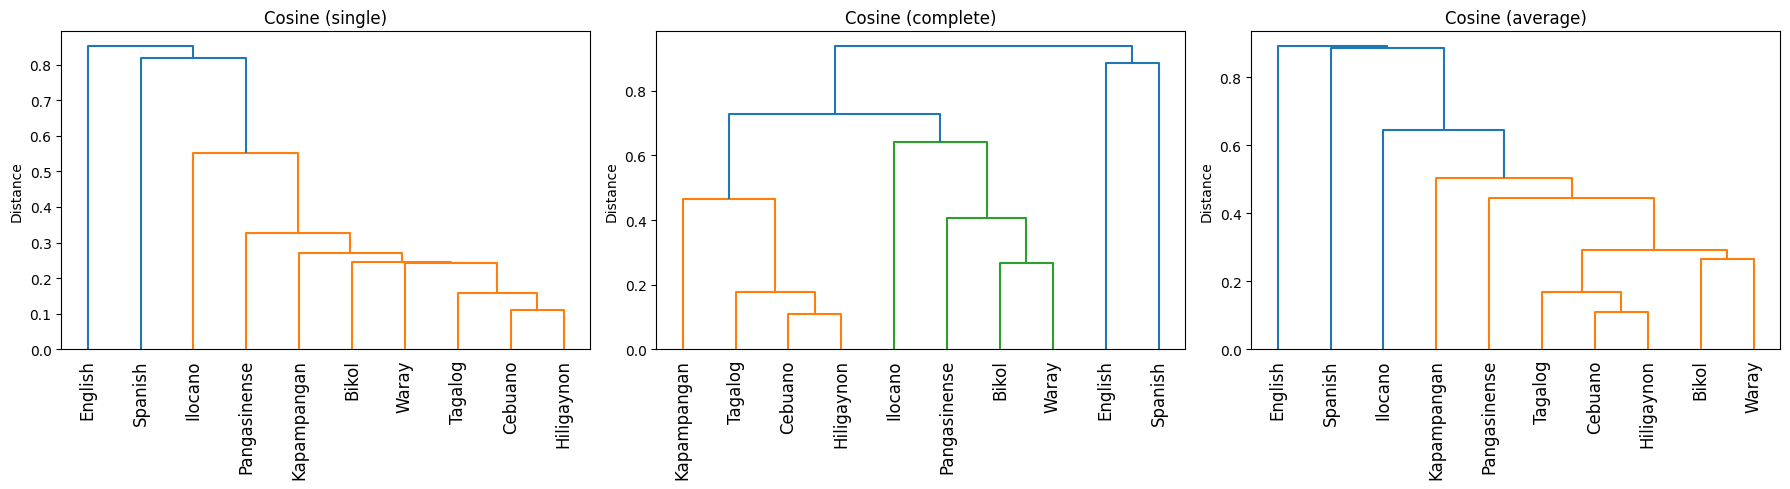

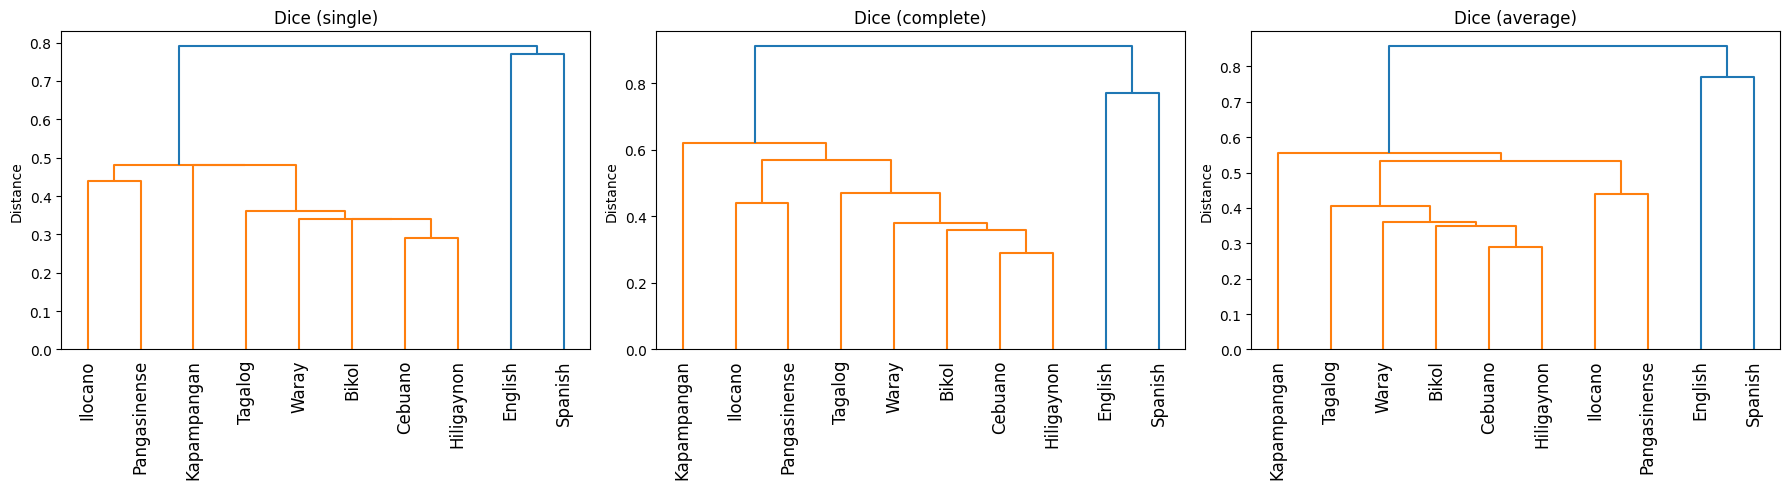

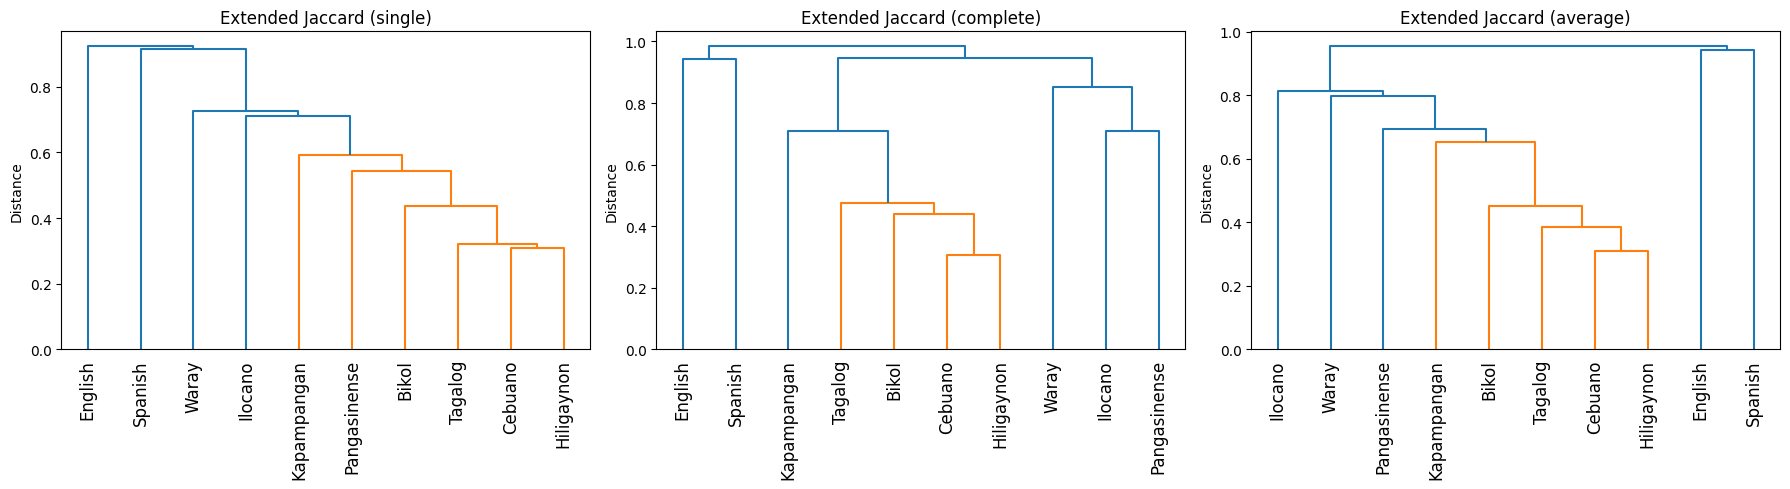

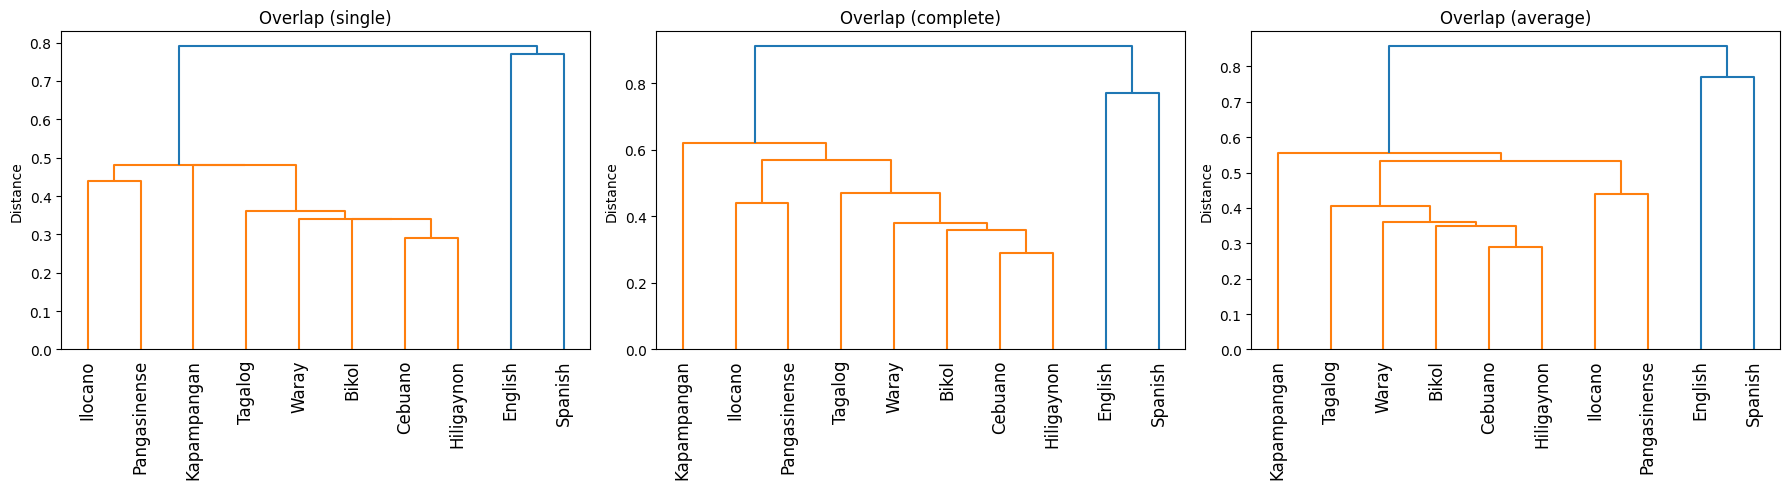

In [84]:
plot_dendrogram(cosine_linkages, "Cosine")
plot_dendrogram(dice_linkages, "Dice")
plot_dendrogram(extended_jaccard_linkages, "Extended Jaccard")
plot_dendrogram(overlap_linkages, "Overlap")

### Digitize Ethnologue Grouping

In [85]:
import networkx as nx
import numpy as np
import pandas as pd
from scipy.spatial.distance import squareform
from scipy.stats import pearsonr
from scipy.cluster.hierarchy import cophenet

# 1. Recreate the Ethnologue tree from the image using edges
G = nx.Graph()
edges = [
    ("Philippine", "Northern Luzon"),
    ("Philippine", "Central Luzon"),
    ("Philippine", "Greater Central Philippine"),
    ("Northern Luzon", "Ilocano"),
    ("Northern Luzon", "Meso-Cordilleran"),
    ("Meso-Cordilleran", "South-Central Cordilleran"),
    ("South-Central Cordilleran", "Southern Cordilleran"),
    ("Southern Cordilleran", "West Southern Cordilleran"),
    ("West Southern Cordilleran", "Pangasinan"),
    ("Central Luzon", "Pampangan"),
    ("Greater Central Philippine", "Central Philippine"),
    ("Central Philippine", "Tagalog"),
    ("Central Philippine", "Bikol"),
    ("Central Philippine", "Bisayan"),
    ("Bisayan", "Cebuan"),
    ("Bisayan", "Central"),
    ("Cebuan", "Cebuano"),
    ("Central", "Hiligaynon"),
    ("Central", "Warayan"),
    ("Warayan", "Samar-Waray"),
    ("Samar-Waray", "Waray-Waray")
]
G.add_edges_from(edges)

# The target languages (brown boxes in the image)
ethno_targets = [
    "Ilocano", "Pangasinan", "Pampangan", "Tagalog", 
    "Bikol", "Cebuano", "Hiligaynon", "Waray-Waray"
]

# Note: Ensure these names match the casing/naming in your 'languages' list. 
# If your corpus uses 'ceb' instead of 'Cebuano', update the target list above 
# or map them dynamically here. Let's assume they match for this script.
valid_langs = [lang for lang in languages if lang in ethno_targets]

# 2. Compute shortest path lengths (Topological Distance)
ethno_matrix = np.zeros((len(valid_langs), len(valid_langs)))

for i, l1 in enumerate(valid_langs):
    for j, l2 in enumerate(valid_langs):
        ethno_matrix[i, j] = nx.shortest_path_length(G, l1, l2)

# 3. Normalize to [0, 1] range to match n-gram distances
ethno_matrix = ethno_matrix / ethno_matrix.max()

ethno_df = pd.DataFrame(ethno_matrix, index=valid_langs, columns=valid_langs)
ethno_condensed = squareform(ethno_matrix, checks=False)

print("Ground-Truth Ethnologue Matrix (Normalized):")
print(ethno_df)

Ground-Truth Ethnologue Matrix (Normalized):
               Bikol   Cebuano  Hiligaynon   Ilocano   Tagalog
Bikol       0.000000  0.571429    0.571429  0.714286  0.285714
Cebuano     0.571429  0.000000    0.571429  1.000000  0.571429
Hiligaynon  0.571429  0.571429    0.000000  1.000000  0.571429
Ilocano     0.714286  1.000000    1.000000  0.000000  0.714286
Tagalog     0.285714  0.571429    0.571429  0.714286  0.000000


In [86]:
def mantel_test(matrix1, matrix2, permutations=10000):
    """
    Computes the Mantel test between two distance matrices.
    Returns the correlation coefficient (r) and the p-value.
    """
    # Ensure matrices are aligned
    m1_cond = squareform(matrix1, checks=False)
    m2_cond = squareform(matrix2, checks=False)
    
    # Observed Pearson correlation
    obs_r, _ = pearsonr(m1_cond, m2_cond)
    
    # Permutation test for significance
    n = matrix1.shape[0]
    permuted_rs = np.zeros(permutations)
    
    for i in range(permutations):
        # Shuffle the matrix rows and columns simultaneously
        idx = np.random.permutation(n)
        m1_permuted = matrix1[idx, :][:, idx]
        m1_perm_cond = squareform(m1_permuted, checks=False)
        
        permuted_rs[i], _ = pearsonr(m1_perm_cond, m2_cond)
        
    # Calculate p-value (proportion of permuted r's greater than or equal to observed r)
    p_value = (np.sum(permuted_rs >= obs_r) + 1) / (permutations + 1)
    
    return obs_r, p_value

# Filter your calculated similarity matrices to match the Ethnologue languages
def get_aligned_distance(sim_df, langs):
    sub_df = sim_df.loc[langs, langs]
    # Convert similarity to distance and clear floating point noise
    dist = 1 - sub_df.values
    dist = (dist + dist.T) / 2
    np.fill_diagonal(dist, 0)
    return np.clip(dist, 0, None)

# Run Mantel Test for all 4 metrics
metrics = {
    "Cosine": get_aligned_distance(cosine_df, valid_langs),
    "Dice": get_aligned_distance(dice_df, valid_langs),
    "Extended Jaccard": get_aligned_distance(jaccard_df, valid_langs),
    "Overlap": get_aligned_distance(overlap_df, valid_langs)
}

print("\n--- MANTEL TEST RESULTS (vs Ethnologue) ---")
for name, dist_matrix in metrics.items():
    r, p = mantel_test(dist_matrix, ethno_matrix)
    print(f"{name:16}: r = {r:.4f} | p-value = {p:.4f}")


--- MANTEL TEST RESULTS (vs Ethnologue) ---
Cosine          : r = 0.7418 | p-value = 0.1858
Dice            : r = 0.7469 | p-value = 0.1190
Extended Jaccard: r = 0.7469 | p-value = 0.1329
Overlap         : r = 0.7469 | p-value = 0.1225


In [87]:
print("\n--- CPCC RESULTS (Dendrogram vs Ethnologue) ---")

# We must recalculate linkages using ONLY the valid languages present in Ethnologue
linkages_filtered = {}
for name, dist_matrix in metrics.items():
    condensed_input = squareform(dist_matrix, checks=False)
    linkages_filtered[name] = {
        method: linkage(condensed_input, method=method) 
        for method in LINKAGE_METHODS
    }

results = []

for metric_name, linkages in linkages_filtered.items():
    for method, Z in linkages.items():
        # Extract the cophenetic distances from the generated tree
        coph_dists = cophenet(Z)
        
        # Correlate the tree's cophenetic distances against ETHNOLOGUE's distances
        cpcc_score, _ = pearsonr(coph_dists, ethno_condensed)
        
        results.append({
            "Metric": metric_name,
            "Linkage": method,
            "CPCC vs Ethnologue": cpcc_score
        })

# Display results sorted by highest accuracy
results_df = pd.DataFrame(results).sort_values("CPCC vs Ethnologue", ascending=False).reset_index(drop=True)
print(results_df.to_string())


--- CPCC RESULTS (Dendrogram vs Ethnologue) ---
              Metric   Linkage  CPCC vs Ethnologue
0               Dice    single            0.756313
1            Overlap    single            0.756313
2   Extended Jaccard  complete            0.754464
3   Extended Jaccard   average            0.752311
4             Cosine    single            0.750586
5             Cosine   average            0.742487
6             Cosine  complete            0.739124
7   Extended Jaccard    single            0.738361
8            Overlap   average            0.736340
9               Dice   average            0.736340
10              Dice  complete            0.721894
11           Overlap  complete            0.721894


=== CPCC EVALUATION MATRIX (vs Ethnologue Ground Truth) ===
| Metric           |   single |   complete |   average |
|:-----------------|---------:|-----------:|----------:|
| Cosine           | 0.750586 |   0.739124 |  0.742487 |
| Dice             | 0.756313 |   0.721894 |  0.73634  |
| Extended Jaccard | 0.738361 |   0.754464 |  0.752311 |
| Overlap          | 0.756313 |   0.721894 |  0.73634  |

🏆 CHAMPION MODEL: Dice + SINGLE (CPCC = 0.7563)


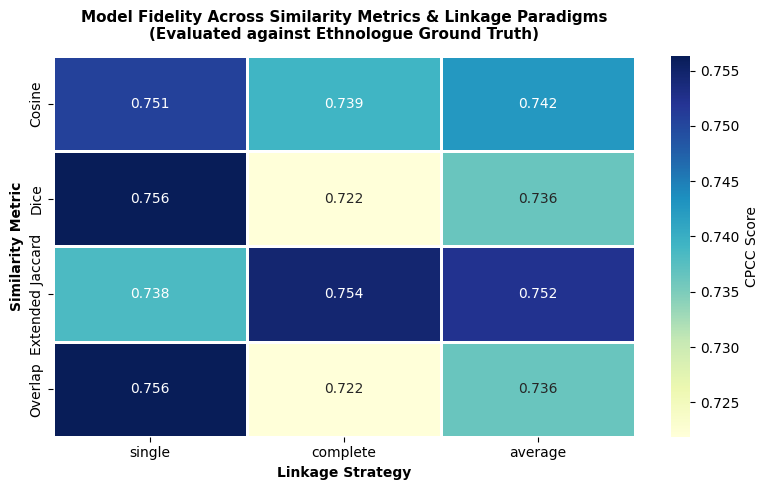

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Pivot results into a clean 4x3 Matrix (Metrics vs Linkages)
cpcc_matrix = results_df.pivot(
    index="Metric", 
    columns="Linkage", 
    values="CPCC vs Ethnologue"
)[["single", "complete", "average"]] # Re-order columns logically

# Re-order rows logically
cpcc_matrix = cpcc_matrix.reindex(["Cosine", "Dice", "Extended Jaccard", "Overlap"])

print("=== CPCC EVALUATION MATRIX (vs Ethnologue Ground Truth) ===")
print(cpcc_matrix.to_markdown())

# 2. Identify and print the Champion
champion_metric = results_df.iloc[0]["Metric"]
champion_linkage = results_df.iloc[0]["Linkage"]
champion_score = results_df.iloc[0]["CPCC vs Ethnologue"]

print(f"\n🏆 CHAMPION MODEL: {champion_metric} + {champion_linkage.upper()} (CPCC = {champion_score:.4f})")

# 3. Generate a High-Resolution Heatmap for Defense Slides / Manuscript
plt.figure(figsize=(8, 5))
sns.heatmap(
    cpcc_matrix, 
    annot=True, 
    fmt=".3f", 
    cmap="YlGnBu", 
    cbar_kws={'label': 'CPCC Score'},
    linewidths=1,
    linecolor='white'
)

plt.title("Model Fidelity Across Similarity Metrics & Linkage Paradigms\n(Evaluated against Ethnologue Ground Truth)", fontsize=11, fontweight='bold', pad=12)
plt.xlabel("Linkage Strategy", fontweight='bold')
plt.ylabel("Similarity Metric", fontweight='bold')
plt.tight_layout()

# Save image for your thesis writeup
plt.savefig("cpcc_model_evaluation_matrix.png", dpi=300)
plt.show()